<a href="https://colab.research.google.com/github/sevenZHQ1018/Econ5200/blob/lab/Class14_Lab14_hangqi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 安装所需库（Colab 环境）
!pip install statsmodels --quiet

## 第1步：环境初始化和基线错觉
**Step 1: Environment Initialization and Naive Baseline Model**

Load the dataset, build a naive OLS regression predicting AI Software Revenue, and observe the deceptively high R² and extremely low p-values — the "baseline illusion."

In [2]:
# ── 导入所有分析库 Import all required libraries ──────────────────────────────
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_white
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


In [3]:
# ── 上传数据集 Upload Dataset ──────────────────────────────────────────────────
# Upload 'Nvidia_AI_Capex_Diagnostics_2026.csv' when prompted
uploaded = files.upload()
import io
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f"✅ Dataset loaded: {filename}")
print(f"   Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\n📋 First 5 rows:")
display(df.head())
print("\n📊 Descriptive Statistics:")
display(df.describe())

Saving Nvidia_AI_Capex_Diagnostics_2026.csv to Nvidia_AI_Capex_Diagnostics_2026.csv
✅ Dataset loaded: Nvidia_AI_Capex_Diagnostics_2026.csv
   Shape: 250 rows × 4 columns

📋 First 5 rows:


,Hardware_Capex,Data_Center_Power_MW,Cloud_GPU_Deployments,AI_Software_Revenue
0,330.91,42.86,86.92,987.76
1,763.04,102.34,95.20,1736.51
2,599.00,86.28,18.97,1020.04
3,498.99,81.70,93.03,1157.51
4,167.01,26.76,51.75,510.83



📊 Descriptive Statistics:


,Hardware_Capex,Data_Center_Power_MW,Cloud_GPU_Deployments,AI_Software_Revenue
count,250.00000,250.000000,250.000000,250.000000
mean,417.81120,63.210360,50.434200,950.498040
std,223.08028,33.855198,27.010512,406.249335
min,53.80000,-5.640000,5.440000,196.480000
25%,223.18500,35.585000,25.512500,594.177500
50%,426.99500,63.390000,48.945000,925.640000
75%,614.96250,91.875000,74.225000,1265.307500
max,790.17000,128.940000,99.050000,1838.510000


In [4]:
# ── 构建朴素基线 OLS 模型 Build Naive Baseline OLS Model ─────────────────────
# Formula: predict AI_Software_Revenue from three regressors
formula = 'AI_Software_Revenue ~ Hardware_Capex + Data_Center_Power_MW + Cloud_GPU_Deployments'

# Fit the model using statsmodels formula API (.fit() executes OLS estimation)
baseline_model = smf.ols(formula, data=df).fit()

print("=" * 65)
print("         NAIVE BASELINE OLS MODEL — THE ILLUSION")
print("=" * 65)
print(baseline_model.summary())
print("\n⚠️  Observation: Notice the suspiciously high R² and near-zero p-values.")
print("    This 'perfect' fit is a diagnostic RED FLAG, not a victory.")

         NAIVE BASELINE OLS MODEL — THE ILLUSION
                             OLS Regression Results                            
Dep. Variable:     AI_Software_Revenue   R-squared:                       0.972
Model:                             OLS   Adj. R-squared:                  0.972
Method:                  Least Squares   F-statistic:                     2831.
Date:                 Tue, 17 Mar 2026   Prob (F-statistic):          2.35e-190
Time:                         18:18:33   Log-Likelihood:                -1409.7
No. Observations:                  250   AIC:                             2827.
Df Residuals:                      246   BIC:                             2841.
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------

## 第2步：残差的视觉取证
**Step 2: Visual Forensics — Residuals vs Fitted Values**

Extract residuals and fitted values, then plot them. A cone-shaped "fan" pattern reveals heteroscedasticity — the error variance is not constant across the range of fitted values.

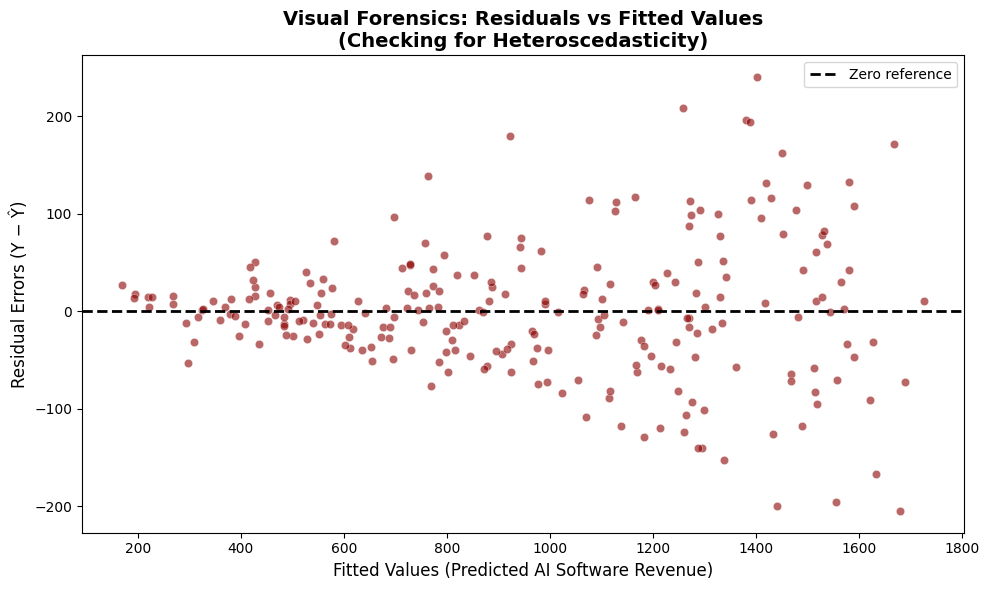


🔍 Interpretation:
   • If residuals fan outward (cone shape) → heteroscedasticity is PRESENT.
   • Ideal homoscedastic case: residuals scatter in a uniform horizontal band.


In [5]:
# ── 提取拟合值和残差 Extract fitted values and residuals ───────────────────────
# .fittedvalues → predicted Ŷ for each observation
# .resid        → raw residuals (Y - Ŷ) for each observation
fitted_vals = baseline_model.fittedvalues
residuals   = baseline_model.resid

# ── 绘制残差图 Plot residuals vs fitted values ─────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    x=fitted_vals, y=residuals,
    alpha=0.6, color='darkred', edgecolor='white', linewidth=0.4,
    ax=ax
)

# Horizontal reference line at zero (ideal: residuals scattered randomly around 0)
ax.axhline(0, color='black', linestyle='--', linewidth=2, label='Zero reference')

ax.set_title(
    'Visual Forensics: Residuals vs Fitted Values\n(Checking for Heteroscedasticity)',
    fontsize=14, fontweight='bold'
)
ax.set_xlabel('Fitted Values (Predicted AI Software Revenue)', fontsize=12)
ax.set_ylabel('Residual Errors (Y − Ŷ)', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("\n🔍 Interpretation:")
print("   • If residuals fan outward (cone shape) → heteroscedasticity is PRESENT.")
print("   • Ideal homoscedastic case: residuals scatter in a uniform horizontal band.")

## 第3步：正式诊断 — White 检验
**Step 3: Formal Diagnostic — The White Test for Heteroscedasticity**

The White test regresses squared residuals on all regressors, their squares, and cross-products. A significant p-value (< 0.05) rejects the null of homoscedasticity.

In [6]:
# ── White 检验执行 White Test Execution ───────────────────────────────────────
# Extract the design matrix (X matrix with intercept) that statsmodels built internally
# model.model.exog gives the exact matrix used in estimation
exog_matrix = baseline_model.model.exog  # shape: (n_obs, n_regressors + 1)

# het_white() takes residuals and the design matrix, returns 4 statistics
white_test_results = het_white(residuals, exog_matrix)

labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
result_dict = dict(zip(labels, white_test_results))

print("=" * 55)
print("            WHITE TEST RESULTS")
print("=" * 55)
for k, v in result_dict.items():
    print(f"  {k:<22}: {v:.6f}")

print()
lm_pval = white_test_results[1]
if lm_pval < 0.05:
    print(f"✅ Conclusion: p-value = {lm_pval:.4f} < 0.05")
    print("   → REJECT H₀ of homoscedasticity.")
    print("   → Heteroscedasticity is statistically CONFIRMED.")
    print("   → Naive OLS standard errors are INVALID. Correction is required.")
else:
    print(f"  p-value = {lm_pval:.4f} ≥ 0.05 → Fail to reject H₀.")
    print("  → No significant evidence of heteroscedasticity.")

            WHITE TEST RESULTS
  LM Statistic          : 57.284553
  LM-Test p-value       : 0.000000
  F-Statistic           : 7.926651
  F-Test p-value        : 0.000000

✅ Conclusion: p-value = 0.0000 < 0.05
   → REJECT H₀ of homoscedasticity.
   → Heteroscedasticity is statistically CONFIRMED.
   → Naive OLS standard errors are INVALID. Correction is required.


## 第4步：诊断多共线性 — 方差膨胀因子 (VIF)
**Step 4: Diagnosing Multicollinearity — Variance Inflation Factors**

VIF for predictor *j* = 1 / (1 − R²_j), where R²_j is from regressing predictor *j* on all other predictors.  
Rule of thumb: VIF > 5 → moderate concern; VIF > 10 → severe multicollinearity.

> ⚠️ **Critical note:** Start the loop at index 1 to skip the intercept column (index 0). Including the intercept in VIF computation causes artificially inflated scores.

In [7]:
# ── VIF 计算循环 Variance Inflation Factor (VIF) Loop ─────────────────────────
# exog_matrix columns: [const, Hardware_Capex, Data_Center_Power_MW, Cloud_GPU_Deployments]
# index 0 = intercept (skip), indices 1-3 = predictors

# Re-define labels here in case this cell is run independently of Step 3
labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']

col_names = baseline_model.model.exog_names  # e.g. ['Intercept', 'Hardware_Capex', ...]

print("=" * 45)
print("       VARIANCE INFLATION FACTORS")
print("=" * 45)
print(f"{'Variable':<30} {'VIF':>8}")
print("-" * 45)

vif_records = []
# Start at 1 to skip the constant intercept column at index 0
for i in range(1, exog_matrix.shape[1]):
    vif = variance_inflation_factor(exog_matrix, i)   # VIF for column i
    var_name = col_names[i]
    vif_records.append({'Variable': var_name, 'VIF': round(vif, 4)})
    flag = ' ⚠️ HIGH' if vif > 10 else (' ⚡ MOD' if vif > 5 else ' ✅ OK')
    print(f"  {var_name:<28} {vif:>8.4f}{flag}")

print("-" * 45)
print("\n📌 Thresholds: VIF > 10 → Severe | VIF 5–10 → Moderate | VIF < 5 → Acceptable")

# Summary DataFrame
vif_df = pd.DataFrame(vif_records)
print("\n📋 VIF Summary Table:")
display(vif_df)

       VARIANCE INFLATION FACTORS
Variable                            VIF
---------------------------------------------
  Hardware_Capex                18.1853 ⚠️ HIGH
  Data_Center_Power_MW          18.1847 ⚠️ HIGH
  Cloud_GPU_Deployments          1.0003 ✅ OK
---------------------------------------------

📌 Thresholds: VIF > 10 → Severe | VIF 5–10 → Moderate | VIF < 5 → Acceptable

📋 VIF Summary Table:


,Variable,VIF
0,Hardware_Capex,18.1853
1,Data_Center_Power_MW,18.1847
2,Cloud_GPU_Deployments,1.0003


## 第5步：数学校正 — HC3 鲁棒标准误差
**Step 5: The Correction — HC3 Heteroscedasticity-Consistent Standard Errors**

Refit the identical OLS formula using `cov_type='HC3'`. HC3 applies a leverage-adjusted sandwich estimator that corrects standard errors for arbitrary heteroscedasticity patterns without changing the coefficient estimates themselves.

In [8]:
# ── HC3 鲁棒标准误差校正 HC3 Robust Standard Errors ──────────────────────────
# cov_type='HC3': heteroscedasticity-consistent covariance matrix (MacKinnon-White estimator)
# Coefficients remain identical to naive OLS; only standard errors change
robust_model = smf.ols(formula, data=df).fit(cov_type='HC3')

print("=" * 65)
print("       ROBUST OLS MODEL — HC3 CORRECTED STANDARD ERRORS")
print("=" * 65)
print(robust_model.summary())

print("\n🔍 Key Observation:")
print("   • Coefficients are IDENTICAL to the naive model.")
print("   • Standard errors are LARGER (corrected for heteroscedasticity).")
print("   • Some previously 'significant' variables may lose significance.")
print("   • This is NOT the model breaking — it is the model becoming HONEST.")

       ROBUST OLS MODEL — HC3 CORRECTED STANDARD ERRORS
                             OLS Regression Results                            
Dep. Variable:     AI_Software_Revenue   R-squared:                       0.972
Model:                             OLS   Adj. R-squared:                  0.972
Method:                  Least Squares   F-statistic:                     2375.
Date:                 Tue, 17 Mar 2026   Prob (F-statistic):          2.91e-181
Time:                         18:18:33   Log-Likelihood:                -1409.7
No. Observations:                  250   AIC:                             2827.
Df Residuals:                      246   BIC:                             2841.
Df Model:                            3                                         
Covariance Type:                   HC3                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------

## 第6步：对比总结 — 朴素 OLS vs HC3 鲁棒模型
**Step 6: Side-by-Side Comparison — Naive OLS vs HC3 Robust**

Compare how standard errors and p-values change once heteroscedasticity is properly corrected.

In [9]:
# ── 系数对比表 Coefficient comparison table ────────────────────────────────────
comparison = pd.DataFrame({
    'Variable':        baseline_model.params.index,
    'Coefficient':     baseline_model.params.values.round(4),
    'Naive SE':        baseline_model.bse.values.round(4),
    'Naive p-value':   baseline_model.pvalues.values.round(4),
    'HC3 SE':          robust_model.bse.values.round(4),
    'HC3 p-value':     robust_model.pvalues.values.round(4),
}).set_index('Variable')

comparison['SE Change %'] = (
    (comparison['HC3 SE'] - comparison['Naive SE']) / comparison['Naive SE'] * 100
).round(2)

print("=" * 75)
print("          NAIVE OLS vs HC3 ROBUST — COEFFICIENT COMPARISON")
print("=" * 75)
display(comparison)

print("\n💡 Interpretation:")
print("   • Positive SE Change % → HC3 inflated SE, p-value likely increased.")
print("   • If HC3 p-value > 0.05 but Naive p-value < 0.05:")
print("     the 'significance' was an artifact of heteroscedasticity.")

          NAIVE OLS vs HC3 ROBUST — COEFFICIENT COMPARISON


,Coefficient,Naive SE,Naive p-value,HC3 SE,HC3 p-value,SE Change %
Variable,,,,,,
Intercept,22.1863,12.4087,0.0750,10.5169,0.0349,-15.25
Hardware_Capex,1.6894,0.0831,0.0000,0.0846,0.0000,1.81
Data_Center_Power_MW,0.3233,0.5474,0.5553,0.5732,0.5728,4.71
Cloud_GPU_Deployments,4.0055,0.1609,0.0000,0.1614,0.0000,0.31



💡 Interpretation:
   • Positive SE Change % → HC3 inflated SE, p-value likely increased.
   • If HC3 p-value > 0.05 but Naive p-value < 0.05:
     the 'significance' was an artifact of heteroscedasticity.


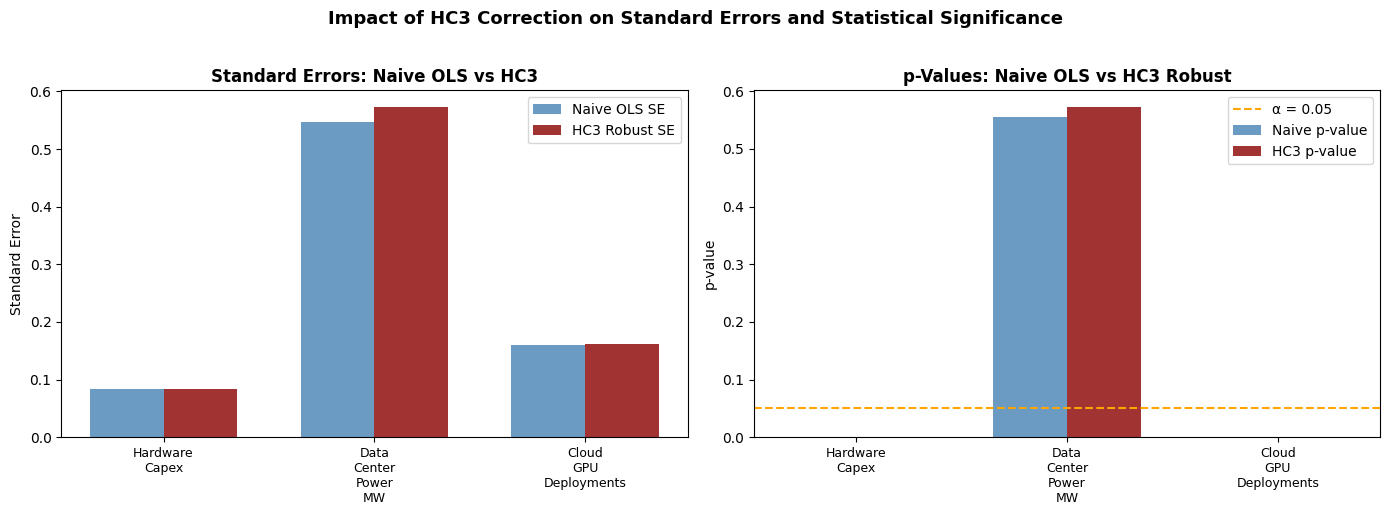

In [10]:
# ── 可视化：标准误差对比柱状图 SE Comparison Bar Chart ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vars_no_const = comparison.index[1:].tolist()  # skip intercept for cleaner plots

# --- Panel 1: Standard Errors comparison ---
x = np.arange(len(vars_no_const))
width = 0.35
axes[0].bar(x - width/2, comparison.loc[vars_no_const, 'Naive SE'],
            width, label='Naive OLS SE', color='steelblue', alpha=0.8)
axes[0].bar(x + width/2, comparison.loc[vars_no_const, 'HC3 SE'],
            width, label='HC3 Robust SE', color='darkred', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels([v.replace('_', '\n') for v in vars_no_const], fontsize=9)
axes[0].set_title('Standard Errors: Naive OLS vs HC3', fontweight='bold')
axes[0].set_ylabel('Standard Error')
axes[0].legend()

# --- Panel 2: p-values comparison ---
axes[1].bar(x - width/2, comparison.loc[vars_no_const, 'Naive p-value'],
            width, label='Naive p-value', color='steelblue', alpha=0.8)
axes[1].bar(x + width/2, comparison.loc[vars_no_const, 'HC3 p-value'],
            width, label='HC3 p-value', color='darkred', alpha=0.8)
axes[1].axhline(0.05, color='orange', linestyle='--', linewidth=1.5, label='α = 0.05')
axes[1].set_xticks(x)
axes[1].set_xticklabels([v.replace('_', '\n') for v in vars_no_const], fontsize=9)
axes[1].set_title('p-Values: Naive OLS vs HC3 Robust', fontweight='bold')
axes[1].set_ylabel('p-value')
axes[1].legend()

plt.suptitle('Impact of HC3 Correction on Standard Errors and Statistical Significance',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()